# Logistic Regression

This is my mini-project using Logistic Regression to accurately predict the survival outcomes of Titanic passengers based on their characteristics. This is a binary classification problem where the target variable is binary (survived or did not survive). Understanding which passenger characteristics were associated with higher survival rates provides valuable insights into the historical patterns during this tragedy and demonstrates the application of statistical learning methods to real-world historical data.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv('titanic_modified_dataset.csv', index_col = 'PassengerId') # Choose PassengerID as index

print(df.head(3))

df = df.to_numpy().astype(np.float64)
m = df.shape[0]

X = df[:, :-1]
y = df[:, -1]

X_bias = np.concatenate((np.ones((m, 1)), X), axis = 1)
print(X_bias)

             Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
PassengerId                                                              
1                 3    0  22.0      1      0   7.2500         0      0   
2                 1    1  38.0      1      0  71.2833         1      1   
3                 3    1  26.0      0      0   7.9250         0      2   

             Survived  
PassengerId            
1                   0  
2                   1  
3                   1  
[[ 1.      3.      0.     ...  7.25    0.      0.    ]
 [ 1.      1.      1.     ... 71.2833  1.      1.    ]
 [ 1.      3.      1.     ...  7.925   0.      2.    ]
 ...
 [ 1.      3.      1.     ... 23.45    0.      2.    ]
 [ 1.      1.      0.     ... 30.      1.      0.    ]
 [ 1.      3.      0.     ...  7.75    2.      0.    ]]


In [118]:
# 2. Split Train, Validation, and Test
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_bias, y,
    test_size = val_size,
    random_state = random_state,
    shuffle = is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)

# 3. Scaling data
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

Epoch  1000/10000 - Train Loss: 0.6633, Val Loss: 0.6660 - Train Acc: 0.7897, Val Acc: 0.7430
Epoch  2000/10000 - Train Loss: 0.6377, Val Loss: 0.6431 - Train Acc: 0.7897, Val Acc: 0.7430
Epoch  3000/10000 - Train Loss: 0.6160, Val Loss: 0.6239 - Train Acc: 0.7897, Val Acc: 0.7430
Epoch  4000/10000 - Train Loss: 0.5964, Val Loss: 0.6077 - Train Acc: 0.7913, Val Acc: 0.7430
Epoch  5000/10000 - Train Loss: 0.5798, Val Loss: 0.5939 - Train Acc: 0.7929, Val Acc: 0.7430
Epoch  6000/10000 - Train Loss: 0.5659, Val Loss: 0.5822 - Train Acc: 0.7929, Val Acc: 0.7430
Epoch  7000/10000 - Train Loss: 0.5563, Val Loss: 0.5721 - Train Acc: 0.7929, Val Acc: 0.7486
Epoch  8000/10000 - Train Loss: 0.5407, Val Loss: 0.5635 - Train Acc: 0.7929, Val Acc: 0.7486
Epoch  9000/10000 - Train Loss: 0.5337, Val Loss: 0.5561 - Train Acc: 0.7913, Val Acc: 0.7486
Epoch 10000/10000 - Train Loss: 0.5275, Val Loss: 0.5496 - Train Acc: 0.7945, Val Acc: 0.7486


Train loss: 0.5275 %
Validation loss: 0.5496 %

Train accu

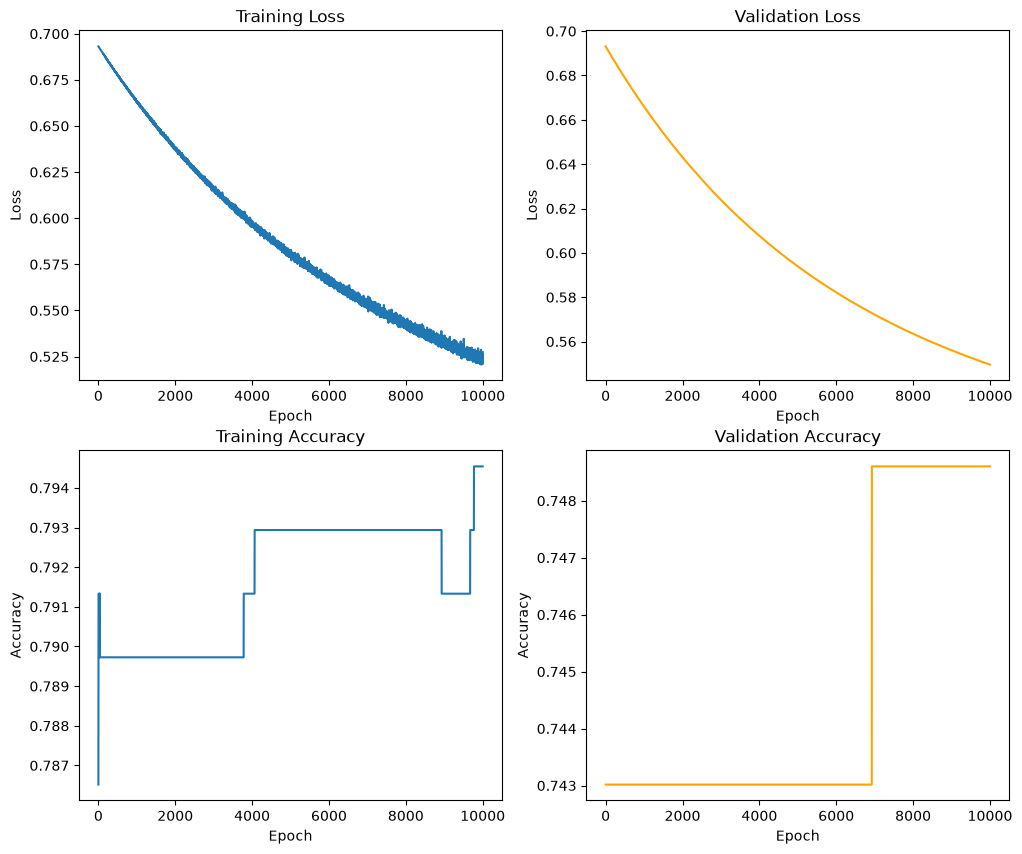

In [119]:
# 4. Important functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict(theta, xi):
    z = np.dot(xi, theta)
    return sigmoid(z)

def compute_loss(yi, prediction):
    prediction = np.clip(prediction, 1e-15, 1 - 1e-15)
    return -(yi * np.log(prediction) + (1 - yi) * np.log(1 - prediction))

def compute_accuracy(y_true, y_predict_prob, threshold = 0.5):
    y_pred_class = (y_predict_prob >= threshold).astype(int)
    accuracy = np.mean(y_pred_class == y_true)
    return accuracy

# 5. Mini-batch logistic regression
def minibatch_logistic_regression(X_train, y_train, X_val, y_val, batch_size = 64, 
                                   epochs = 10000, learning_rate = 1e-5):
    (m, n) = X_train.shape
    theta = np.zeros(n)
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
        train_loss = 0

        indecies = np.random.permutation(m)
        X_shuffled = X_train[indecies]
        y_shuffled = y_train[indecies]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i: i + batch_size]
            y_batch = y_shuffled[i: i + batch_size]

            y_pred = predict(theta, X_batch)
            error = y_batch - y_pred
            theta = theta + (learning_rate / len(y_batch)) * (X_batch.T @ error)
            train_loss += np.mean(compute_loss(y_batch, y_pred))

        num_batches = (m + batch_size - 1) // batch_size
        avg_train_loss = train_loss / num_batches
        train_losses.append(avg_train_loss)
        
        y_val_pred = predict(theta, X_val)
        val_loss = compute_loss(y_val, y_val_pred)
        avg_val_loss = np.mean(val_loss)
        val_losses.append(avg_val_loss)
        
        train_acc = compute_accuracy(y_train, predict(theta, X_train))
        val_acc = compute_accuracy(y_val, y_val_pred)
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # Print progress
        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1:5d}/{epochs} - "
                  f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f} - "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    return theta, train_losses, val_losses, train_accuracies, val_accuracies

# 6. Print answer and plot diagram
theta, train_losses, val_losses, train_accs, val_accs = minibatch_logistic_regression(X_train, y_train, X_val, y_val, 32, 10000, 1e-5)

fig, ax = plt.subplots(2, 2, figsize = (12, 10))
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel = 'Epoch', ylabel = 'Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel = 'Epoch', ylabel = 'Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel = 'Epoch', ylabel = 'Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel = 'Epoch', ylabel = 'Accuracy')
ax[1, 1].set_title('Validation Accuracy')

# 7. Evaluate:
train_acc = train_accs[-1]
val_acc = val_accs[-1]
train_loss = train_losses[-1]
val_loss = val_losses[-1]
test_acc = compute_accuracy(y_test, predict(theta, X_test))

print("\n")
print(f"Train loss: {train_loss:.4f} %")
print(f"Validation loss: {val_loss:.4f} %\n")

print(f"Train accuracy: {train_acc * 100:.4f} %")
print(f"Validation accuracy: {val_acc * 100:.4f} %")
print(f"Test accuracy: {test_acc * 100:.4f} %")